In [675]:
import torch
import time
import imageio
import random
import numpy as np
import pandas as pd 
import torch.nn as nn
import seaborn as sns
import torch.optim as optim
from torchdiffeq import odeint
import matplotlib.pyplot as plt
from IPython.display import clear_output
import torch.nn.functional as F

In [676]:
def set_seed(seed):
	torch.manual_seed(seed)
	np.random.seed(seed)
	random.seed(seed)
	if torch.cuda.is_available(): 
		torch.cuda.manual_seed(seed)
set_seed(42) # For reproducibility

## ODE Solver

In [677]:
def euler_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim])
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0
	for i in range(1, len(t)): 
		dt = t[i] - t[i - 1]
		y = y + func(t[i - 1], y) * dt
		ys.append(y)

	return torch.stack(ys, dim=0)  # shape: [T, batch, dim]

In [678]:
def improved_euler_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim] 
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = y + k1 * dt
		y = y + (k1 + func(t[i], k2)) * dt / 2
		ys.append(y)
	return torch.stack(ys, dim=0)


In [679]:
def rk2_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim]
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
		y = y + k2 * dt
		ys.append(y)
	return torch.stack(ys, dim=0)

In [680]:
def rk4_solver(func, y0, t):
	"""
	func: ODE function f(t, y)
	y0: initial state (tensor: [batch, dim]
	t: time tensor, shape [T]
	"""
	ys = [y0]
	y = y0 
	for i in range(1, len(t)):
		dt = t[i] - t[i - 1]
		k1 = func(t[i-1], y)
		k2 = func(t[i-1] + dt/2, y + k1 * dt / 2)
		k3 = func(t[i-1] + dt/2, y + k2 * dt / 2)
		k4 = func(t[i-1] + dt, y + k3 * dt)
		y = y + (k1 + 2*k2 + 2*k3 + k4) * dt / 6
		ys.append(y)
	return torch.stack(ys, dim=0)

## Neural ODE

In [681]:
class ODEFunc(nn.Module):
	def __init__(self):
		super().__init__()
		self.net = nn.Sequential(nn.Linear(4, 20),
										nn.Tanh(),
										nn.Linear(20, 4))
		for m in self.net.modules(): 
			if isinstance(m, nn.Linear): 
				nn.init.normal_(m.weight, mean=0, std=0.1)
				nn.init.constant_(m.bias, val=0)

	def forward(self, t, y):
		output = self.net(y)

		damping = -0.03 * y # damping to ensure stability 
		output = output + damping

		return output

## Data Processing

In [ ]:
# Load simulation data
data = pd.read_csv('/Users/vanessahuo/Documents/GitHub/MAT292_ODE_Project/FINAL_mrgsolve_simulation.csv')
data = pd.read_csv('../FINAL_mrgsolve_simulation.csv')

# Convert data to numpy arrays
t_np = data['time'].values.astype(np.float32)
C1_np = data['CENT'].values.astype(np.float32)
C2_np = data['PERIPH'].values.astype(np.float32)
C3_np = data['PERIPH2'].values.astype(np.float32)
C4_np = data['CP'].values.astype(np.float32)

# Verify shapes of the arrays
print(t_np.shape, C1_np.shape, C2_np.shape, C3_np.shape, C4_np.shape)

(481,) (481,) (481,) (481,) (481,)


In [683]:
def data_processing(t_np, c1, c2, c3, c4, ratio=0.8, split=True):
	"""
	Prepares time and concentration data for Neural ODE training.
	If split=True:
		- Splits dataset into train/test based on ratio 
		- Computes mu, sigma only from train data
		- Normalizes both train and test using train mean and std
	If split=False:
		- No splitting
		- Normalize entire dataset using global mu/sigma
	"""
	t = torch.tensor(t_np, dtype=torch.float32)
	C1 = torch.tensor(c1, dtype=torch.float32)
	C2 = torch.tensor(c2, dtype=torch.float32)
	C3 = torch.tensor(c3, dtype=torch.float32)
	C4 = torch.tensor(c4, dtype=torch.float32)
	print("Shapes:", C1.shape, C2.shape, C3.shape, C4.shape)

	C_all = torch.stack([C1, C2, C3, C4], dim=1)

	# Add batch dimension -> [T, 1, 4] 
	C_all = C_all.unsqueeze(1)

	# No splitting 
	if not split:
		mu = C_all.mean(dim=0, keepdim=True) # shape [1,1,4]
		sigma = C_all.std(dim=0, keepdim=True) + 1e-8

		C_all_norm = (C_all - mu) / sigma

		train_C_norm = C_all_norm
		train_t = t
	else: 
		# Splitting 
		data_size = C_all.shape[0]
		split_idx = int(data_size * ratio)

		train_C = C_all[:split_idx] 
		train_t = t[:split_idx]
		test_C = C_all[split_idx:] 
		test_t = t[split_idx:]

		mu = train_C.mean(dim=0, keepdim=True)
		sigma = train_C.std(dim=0, keepdim=True) + 1e-8

		# Normalize train and test using Train mean and standard deviation
		train_C_norm = (train_C - mu) / sigma
		test_C_norm = (test_C - mu) / sigma

		# Combine normalized back for full C_all if needed
		C_all_norm = torch.cat([train_C_norm, test_C_norm], dim=0)

	return {
		"t": t,
		"C_all": C_all_norm,
		"mu": mu,
		"sigma": sigma,
		"split_idx": split_idx if split else None,
		"train_C": train_C_norm,
		"train_t": train_t,
		"test_C": test_C_norm if split else None,
		"test_t": test_t if split else None
	}

In [684]:
def get_batch(C, t, batch_time, batch_size):
	data_size = C.shape[0]
	s = torch.from_numpy(np.random.choice(np.arange(data_size - batch_time, dtype=np.int64), batch_size, replace=False))
	batch_c0 = C[s]  # (batch_size, 1, emb)
	batch_t = t[:batch_time]  # (T)
	batch_c = torch.stack([C[s + i] for i in range(batch_time)], dim=0)  # (time, batch_size, 1, emb)
	return batch_c0, batch_t, batch_c

In [685]:
def visualize(data_dict, pred_all):
	'''
		t torch.Size([97])
		C_all torch.Size([97, 1, 4])
		mu torch.Size([1, 1, 4])
		sigma torch.Size([1, 1, 4])
		split_idx 77
		train_C torch.Size([77, 1, 4])
		train_t torch.Size([77])
		test_C torch.Size([20, 1, 4])
		test_t torch.Size([20])
	'''
	t = data_dict["t"]
	C_all = data_dict["C_all"].squeeze(1)
	pred_all = pred_all.squeeze(1)

	mu = data_dict["mu"].squeeze(0)
	sigma = data_dict["sigma"].squeeze(0)

	split_idx = data_dict.get("split_idx", None)
	test_t = data_dict.get("test_t", None)

	ture_all_orig = C_all * sigma + mu
	pred_all_orig = pred_all * sigma + mu

	fig = plt.figure(figsize=(10,6), constrained_layout=True)
	colors = ['blue', 'orange', 'green', 'red']
	compartment = ['Central', 'Peripheral 1', 'Peripheral 2', 'CP']

	if split_idx is not None:
		t_train = t[:split_idx]
		true_train = ture_all_orig[:split_idx]
		pred_train = pred_all_orig[:split_idx]
	else: 
		t_train = t
		true_train = ture_all_orig
		pred_train = pred_all_orig

	for i in range(4):
		plt.scatter(t_train, true_train[:,i], color=colors[i], marker='o', alpha=0.3, label=f'True {compartment[i]}', s=5)
		plt.plot(t_train, pred_train[:,i], linestyle='-', color=colors[i], label=f'Train Pred {compartment[i]}')

	if split_idx is not None and test_t is not None:
		t_test = t[split_idx:]
		true_test = ture_all_orig[split_idx:]
		pred_test = pred_all_orig[split_idx:]
		for i in range(4):
			plt.scatter(test_t, true_test[:,i], color=colors[i], marker='o', s=5)
			plt.plot(t_test, pred_test[:,i], linestyle='--', color=colors[i], label=f'Test Pred {compartment[i]}')
		plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2, label="Train/Test Split")

	plt.xlabel('Time (hr)')
	plt.ylabel('Amount (mg)')
	plt.title(f'True vs Predicted Amounts')
	plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left') 
	plt.grid(True)
	plt.show()
	return fig

In [686]:
def plot_loss(train_loss, test_loss=None, niters=400, log_every=20):
	plt.figure(figsize=(10, 6))
	
	x_axis = np.arange(0, niters+1, log_every)
	
	plt.plot(x_axis, train_loss, '-', markersize=3, label="Train Loss")
	
	if test_loss is not None and len(test_loss) > 0:
		plt.plot(x_axis, test_loss, label="Test Loss")
	plt.xlabel("Iteration")
	plt.ylabel("Loss")
	plt.title("Training and Test Loss Over Iterations")
	plt.legend()
	plt.grid(True)
	plt.show()

In [687]:
def train_NODE(data_dict, solver, niters=400, lr=1e-3, batch_size=1, gif=False):
	func = ODEFunc()
	optimizer = optim.Adam(func.parameters(), lr=lr, weight_decay = 1e-4)
	train_loss_history = []
	test_loss_history = []
	criterion = nn.MSELoss()

	# Only create frame storage if gif=True
	frames = [] if gif else None

	start_time = time.time()
	
	t = data_dict["t"]
	C_all = data_dict["C_all"]

	train_C = data_dict["train_C"]
	train_t = data_dict["train_t"]
	test_C  = data_dict.get("test_C", None)
	test_t  = data_dict.get("test_t", None)
	
	C_0 = train_C[0, 0, :].unsqueeze(0)
	train_size = train_C.shape[0]
	batch_time = train_size - 1

	# --- main training loop ---
	for iter in range(niters + 1):
		optimizer.zero_grad()
		batch_c0, batch_t, batch_c = get_batch(train_C, train_t, batch_time, batch_size)

		pred_C = solver(func, batch_c0, batch_t)

		# Batch loss
		loss = torch.sqrt(criterion(pred_C, batch_c)) # Compute using RMSE loss 
		# loss = criterion(pred_C, batch_c) # Compute using MSE loss 
		loss.backward()
		optimizer.step()
		if iter % 20 == 0 or iter == niters:
			with torch.no_grad():
				pred_train = solver(func, C_0, train_t)

				train_loss = torch.sqrt(criterion(pred_train, train_C)) # Compute using RMSE loss 
				# train_loss = criterion(pred_train, train_C) # Compute using MSE loss 

				train_loss_history.append(train_loss.item())
				# Move test evaluation to a separate block or keep it strictly for logging
				if test_C is not None:
					test_start_state = pred_train[-1] 
					pred_test = solver(func, test_start_state, test_t)

					test_loss = torch.sqrt(criterion(pred_test, test_C))  # Compute using RMSE loss 
					# test_loss = criterion(pred_test, test_C) # Compute using MSE loss 
					test_loss_history.append(test_loss.item()) 
				else:
					test_loss = None
				print(f"Iter {iter:04d} | Total Loss {train_loss.item():.6f} | Test Loss: {test_loss.item():.6f}" if test_loss is not None else 'N/A')

		if iter % 50 == 0:
			with torch.no_grad():
				clear_output(wait=True)
				# Only save frames if gif=True
				# always show visualization
				pred_all = solver(func, C_0, t)
				fig = visualize(data_dict, pred_all)
				if gif:
					fig.canvas.draw()
					buf = fig.canvas.buffer_rgba()
					image = np.asarray(buf, dtype=np.uint8)
					frames.append(image)
				plt.close(fig)
	print(f"Final Train Loss {train_loss_history[-1]:.6f} | Test Loss: {test_loss_history[-1]:.6f}" if test_loss is not None else 'N/A')
	
	with torch.no_grad():
		pred_all_C = solver(func, C_0, t)
		pred_train_C = pred_all_C[:len(train_t)]
		pred_test_C = pred_all_C[len(train_t):] if test_C is not None else None

	plot_loss(train_loss_history, test_loss_history, niters, 20)

	# Save GIF only when user requests it
	if gif:
		imageio.mimsave(f"../../images/training_animation_{solver}.gif", frames, fps=2)
		print("Saved GIF: training_animation.gif")

	print(f"Process time: {time.time() - start_time:.2f} sec")
	return pred_train_C, pred_test_C, func

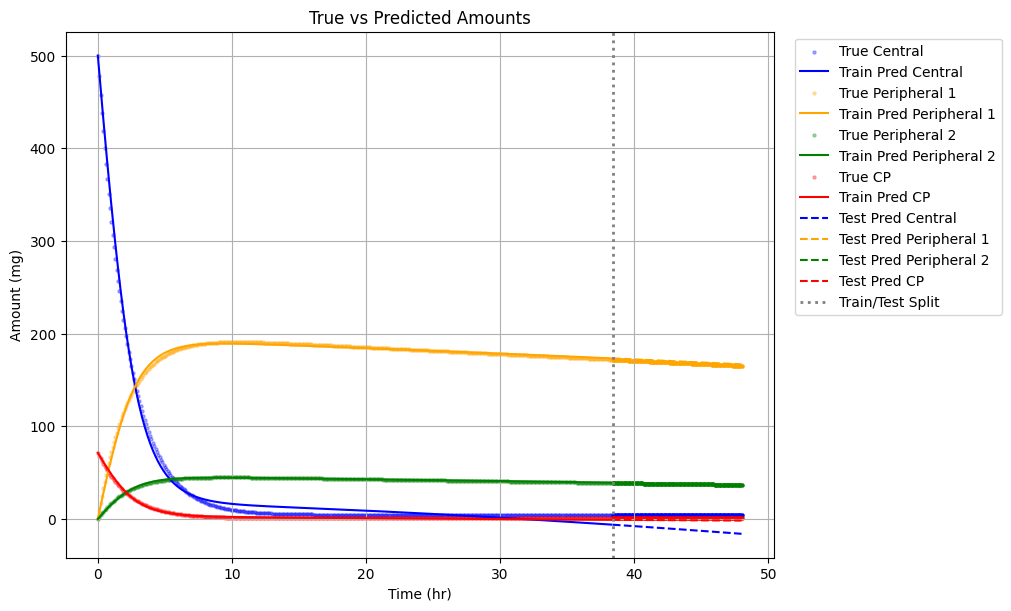

Final Train Loss 0.071150 | Test Loss: 0.130291


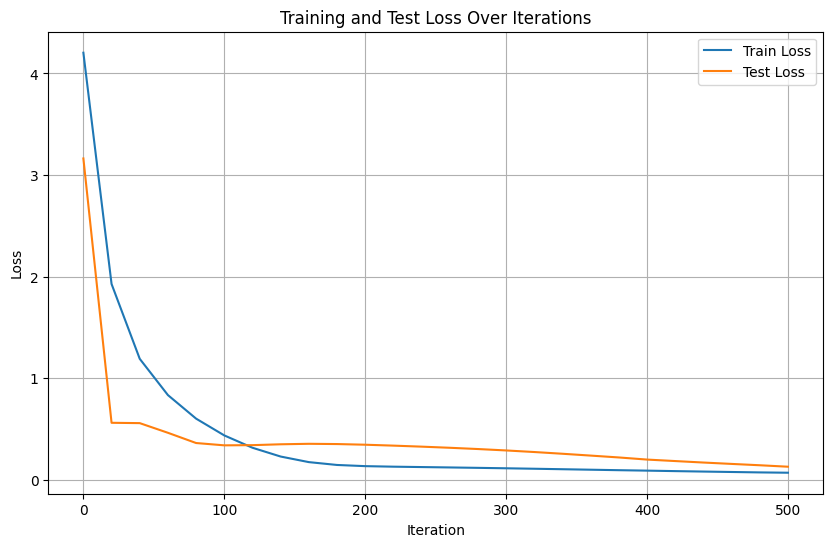

Saved GIF: training_animation.gif
Process time: 53.07 sec


In [688]:
# Solve using Euler method 
data_dict = data_processing(t_np, C1_np, C2_np, C3_np, C4_np, ratio=0.8, split=True)
pred_train_C, pred_test_C, func = train_NODE(data_dict, improved_euler_solver, niters = 500, lr=1e-3, batch_size=1, gif=True)

In [689]:
# # Solve using Improved Euler method
# pred_train_C, pred_test_C, func = train_NODE(data_dict, improved_euler_solver, niters = 600, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [690]:
# # Solve using runge-Kutta 4th order method
# pred_train_C, pred_test_C, func = train_NODE(data_dict, rk4_solver, niters = 800, lr=5e-4, batch_size=1, method='dopri5', gif=True)

In [691]:
print(pred_train_C.shape)
print(data_dict['train_C'].shape)

torch.Size([384, 1, 4])
torch.Size([384, 1, 4])


## Evaluation

Residual 

In [692]:
def plot_residual(t, train_C, test_C, final_train_pred, final_test_pred = None, split_idx = None):
	eps = 1e-3
	train_residual = ((train_C - final_train_pred)).squeeze(1)
	test_residual = ((test_C - final_test_pred)).squeeze(1) if test_C is not None else None
	colors = ['blue', 'orange', 'green', 'red']
	plt.figure(figsize=(10,6))
	if split_idx is None:
			split_idx = len(train_residual) 
			print(len(train_residual))
	
	for i in range(4):
		plt.scatter(t[:split_idx], train_residual[:, i], color=colors[i], alpha = 0.5, s=6, label=f"Train Residual {i+1}")
		if test_residual is not None:
			plt.scatter(t[split_idx:], test_residual[:, i], color=colors[i], marker='+', s=8,label=f"Test Residual {i+1}")
	if test_residual is not None:
			plt.axvline(t[split_idx], color='gray', linestyle=':', linewidth=2, label="Train/Test Split")
	print("Max Train Residual:", train_residual.max(), "Max Test Residual:", test_residual.max() if test_residual is not None else "N/A")
	plt.xlabel("Time")
	plt.ylabel("Residual (True - Pred) (mg)")
	plt.title("Unnormalized Residual vs Time (Train + Test)")
	plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.grid(True)
	plt.show()

Max Train Residual: tensor(0.2648) Max Test Residual: tensor(0.2451)


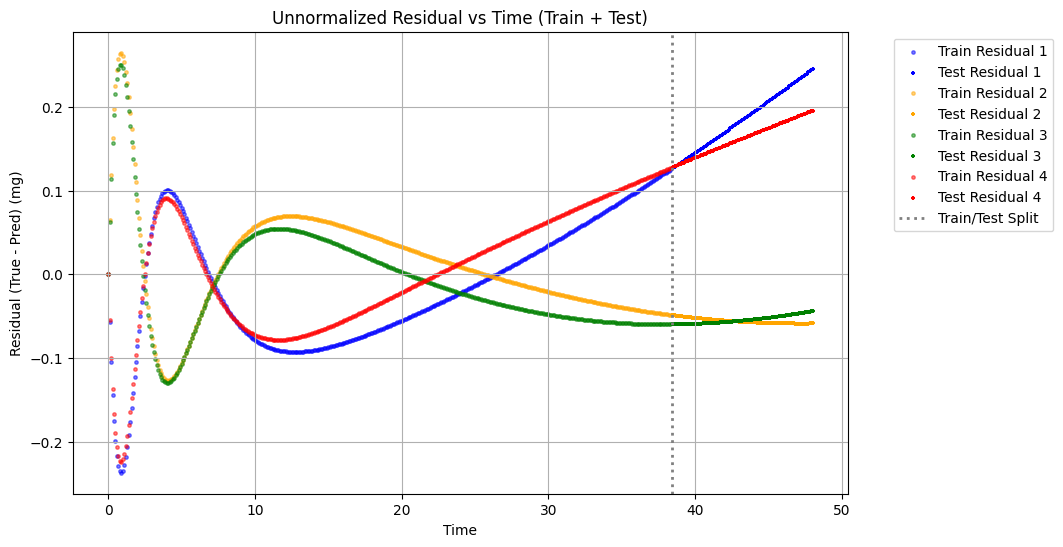

In [693]:
plot_residual(data_dict['t'], data_dict['train_C'], data_dict['test_C'], pred_train_C, pred_test_C, split_idx = data_dict['split_idx'])

Sensitivity to Initial Conditions

In [694]:
def init_sensitivity(data_dict, solver, func):
	func.eval()
	eps = 1e-3
	
	# Prepare Initial Condition
	C0 = data_dict['train_C'][0, 0, :].clone().detach().requires_grad_(True)
	t = data_dict['t']

	# Compute Jacobian of the solver w.r.t C0
	def get_traj(c_init):
		return solver(func, c_init.unsqueeze(0), t).squeeze(1)

	jac = torch.autograd.functional.jacobian(get_traj, C0) 

	# Calculate Relative Sensitivity (Dimensionless)
	with torch.no_grad():
		pred = get_traj(C0)
		# Relative Sens = (dC_out / dC_in) * (C_in / C_out)
		# Use broadcasting: jac is [T, D_out, D_in], C0 is [D_in], pred is [T, D_out]
		rel_sens = jac * (C0.view(1, 1, -1) / (pred.unsqueeze(-1) + eps))

	global_map = rel_sens.abs().mean(dim=0).detach().cpu().numpy()
	
	plt.figure(figsize=(8, 6))
	sns.heatmap(global_map, annot=True, fmt=".2f", cmap="YlGnBu",
				xticklabels=[f"C{i+1}(0)" for i in range(C0.shape[0])],
				yticklabels=[f"C{i+1}(t)" for i in range(C0.shape[0])])
	
	plt.title("Influence of Initial Conditions (Relative %)")
	plt.xlabel("Input: Initial State")
	plt.ylabel("Output: Trajectory Component")
	plt.show()

	return rel_sens

Sensitivity to Neural ODE Parameters

In [695]:
def param_sensitivity(data_dict, solver, func):
	func.eval()
	train_C = data_dict['train_C']
	t = data_dict['t']
	C_0 = train_C[0, 0, :].unsqueeze(0)
	for name, p in func.named_parameters():
		  print(name, p.shape)
	
	last_pred_C = solver(func, C_0, t)[-1]
	sensitivity = torch.autograd.grad(last_pred_C.sum(), func.parameters(), create_graph=True)

	eps = 1e-6
	for (name, p), grad in zip(func.named_parameters(), sensitivity):
		rel_sens = (grad * p / (last_pred_C.abs().mean() + eps)).detach()
		if rel_sens.ndim == 2: 
			plt.figure(figsize=(8,6))
			sns.heatmap(rel_sens.detach().abs().cpu(), cmap="viridis")
			plt.title(f"Sensitivity heatmap: {name}")
			plt.xlabel("Input")
			plt.ylabel("Hidden unit")
			plt.show() 

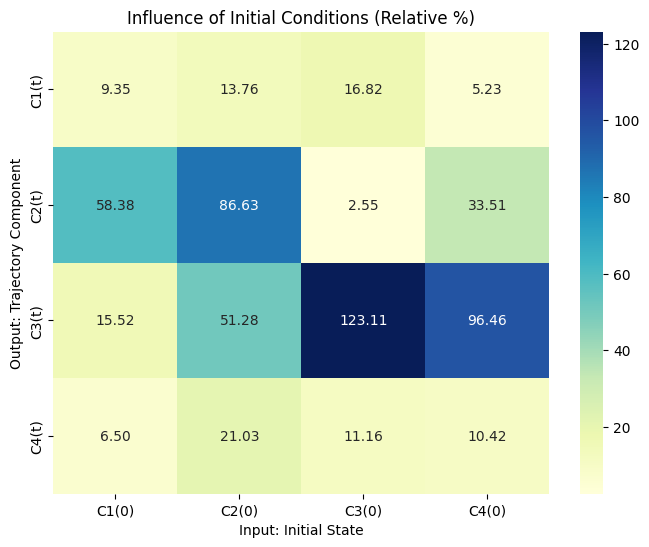

net.0.weight torch.Size([20, 4])
net.0.bias torch.Size([20])
net.2.weight torch.Size([4, 20])
net.2.bias torch.Size([4])


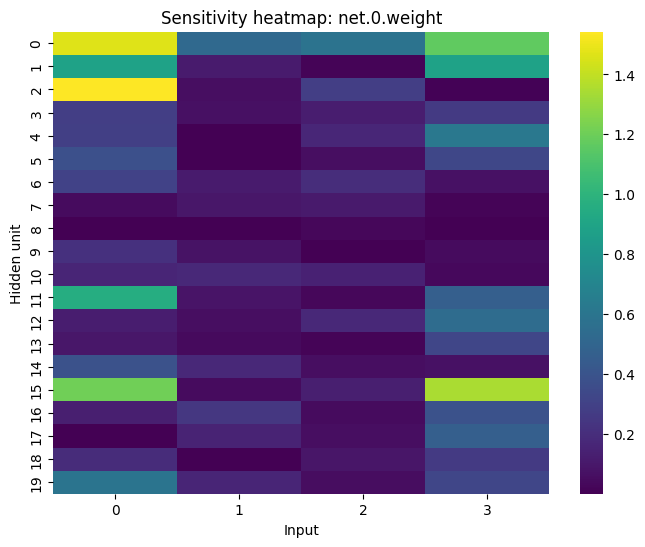

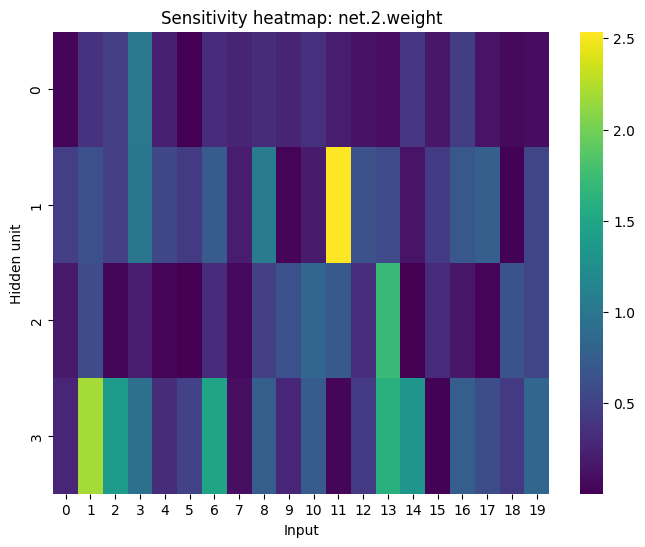

In [696]:
init_sen = init_sensitivity(data_dict, improved_euler_solver, func)
param_sensitivity(data_dict, improved_euler_solver, func)

In [697]:
from scipy.optimize import fsolve

def find_fixed_points(node_func, initial_guess, t=0):
	def func_to_solve(c_array):
		# Convert numpy array from solver to torch tensor
		c_torch = torch.tensor(c_array, dtype=torch.float32).reshape(1, 4)
		# Get the derivative from the Neural ODE
		with torch.no_grad():
			derivative = node_func(t, c_torch)
		return derivative.numpy().flatten()

	# Solve for where derivative == 0
	fixed_point, info, ier, msg = fsolve(func_to_solve, initial_guess, full_output=True)
	return fixed_point

initial_guess = np.array([0.1, 0.1, 0.1, 0.1])
fixed_point = find_fixed_points(func, initial_guess)
print("Fixed Point Found:", fixed_point)

Fixed Point Found: [0.64282405 3.15482841 3.65892417 0.96104402]


In [702]:
def check_linear_stability(func, current_state, t=0):
	func.eval()
	C = current_state.clone().detach().requires_grad_(True)
	# Define the function for the Jacobian (f(C, t))
	def ode_rhs(c_input):
		return func(t, c_input)
	# Compute Jacobian [Dim, Dim]
	jac = torch.autograd.functional.jacobian(ode_rhs, C).squeeze()

	# Compute Eigenvalues
	eigenvalues = torch.linalg.eigvals(jac.detach().cpu())
	real_parts = eigenvalues.real

	# Interpret Results
	is_stable = torch.all(real_parts < 0)
	
	print(f"Eigenvalues: {eigenvalues}")
	print(f"Max Real Part: {torch.max(real_parts):.4f}")
	print(f"System is {'STABLE' if is_stable else 'UNSTABLE'} at this point.")
	
	return eigenvalues

In [703]:
for i in range(380):
	currentstate = pred_train_C[i]
	check_linear_stability(func,  currentstate, t=28)

Eigenvalues: tensor([-0.1136+0.0000j, -0.0251+0.0202j, -0.0251-0.0202j, -0.0249+0.0000j])
Max Real Part: -0.0249
System is STABLE at this point.
Eigenvalues: tensor([-0.1224+0.0000j, -0.0246+0.0209j, -0.0246-0.0209j, -0.0243+0.0000j])
Max Real Part: -0.0243
System is STABLE at this point.
Eigenvalues: tensor([-0.1320+0.0000j, -0.0241+0.0217j, -0.0241-0.0217j, -0.0236+0.0000j])
Max Real Part: -0.0236
System is STABLE at this point.
Eigenvalues: tensor([-0.1425+0.0000j, -0.0235+0.0225j, -0.0235-0.0225j, -0.0228+0.0000j])
Max Real Part: -0.0228
System is STABLE at this point.
Eigenvalues: tensor([-0.1538+0.0000j, -0.0228+0.0233j, -0.0228-0.0233j, -0.0220+0.0000j])
Max Real Part: -0.0220
System is STABLE at this point.
Eigenvalues: tensor([-0.1659+0.0000j, -0.0221+0.0240j, -0.0221-0.0240j, -0.0211+0.0000j])
Max Real Part: -0.0211
System is STABLE at this point.
Eigenvalues: tensor([-0.1790+0.0000j, -0.0213+0.0248j, -0.0213-0.0248j, -0.0201+0.0000j])
Max Real Part: -0.0201
System is STABLE 